# Check responsivity to Emotional faces across all (pre)screened contacts for participant
Specifically designed for EmotionTask data <br>

____
**tl;dr** <br>
Group analysis of ERPs from Emotional Faces task 
- Just ERP scalars to assess responsiveness and selectivity<br>
____
**Prerequisites:** <br>
Files
- *ERPdata.csv for each participant (in their EmotionTask folder)<br>

Code
- numpy
- pandas
- matplotlib
- scipy
- my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)


### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import os
import re
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

import statsmodels.api as sm

# instantiate a random number generator
rng = np.random.default_rng()

### Load data/metadata

In [2]:
# use file selection dialog to choose folder with data
# Select PARENT folder with *all* emotional faces data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data


In [8]:
# load ERP_data
os.listdir(fstr)
ID_pat = r'^[A-Za-z0-9]{6}$'
fldr_pat = "EmotionTask"

df_list = []
for ID in os.listdir(fstr):
    if re.fullmatch(ID_pat,ID):
        try:
            loadstr = fstr+"\\"+rf"{ID}\EmotionTask\EmotionTask_{ID}_HFBdata.csv"
            df_list.append(pd.read_csv(loadstr, delimiter=","))
        except:
            print(f"Couldn't find data for {ID}")
ERP_df = pd.concat(df_list,ignore_index=True)

Couldn't find data for 542fcb


In [9]:
# add systems identifiers
limbic = ["hip", "amy", "entorhinal","insula","orbit","cingulate"]
assoc = ["supramarginal","middletemporal","inferiortemporal","temporalpole","supramarginal","parietal","frontal","pars"]
sensmo = ["lingual","cuneus","precentral","postcentral","calcarine","fusiform","superiortemporal"]

systems = []
for r in ERP_df.region:
    if any([limbic[ix] in r.lower() for ix in range(len(limbic))]):
        systems.append("limbic")
    # elif any([frontal[ix] in r.lower() for ix in range(len(frontal))]):
    #     systems.append("frontal")
    elif any([assoc[ix] in r.lower() for ix in range(len(assoc))]):
        systems.append("association")
    elif any([sensmo[ix] in r.lower() for ix in range(len(sensmo))]):
        systems.append("sensorimotor")
    else:
        print("?",r)
        systems.append("?")

ERP_df["system"] = systems

In [5]:
ERP_df

,ID,age,region,contacts,value,variable,category,system
0,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,-6.617720,normamp,anger,association
1,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,0.216216,latency,anger,association
2,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,0.203125,event_dur,anger,association
3,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,-3.526208,normamp,fear,association
4,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,0.589385,latency,fear,association
...,...,...,...,...,...,...,...,...
1165,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,0.304688,event_dur,neutral,limbic
1166,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,-11.434168,normamp,happy,limbic
1167,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,0.644090,latency,happy,limbic
1168,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,0.183594,event_dur,happy,limbic


In [10]:
# make all amps positive
amps = ERP_df.value[ERP_df.variable=="normamp"]
ERP_df.loc[ERP_df.variable=="normamp","value"] = np.abs(amps)
gby = ERP_df.drop(columns=["contacts","region","category"]).groupby(by=["ID","system","variable"]).agg(
    {"age":"mean","value":"mean"}).reset_index().sort_values(by="age")

association
p = 0.1564352370079131
r^2 = 0.02958552691130356
n = 37.0
t = -1.448292298211712
limbic
p = 0.029666946566781063
r^2 = 0.12783846226465045
n = 30.0
t = -2.29144518764084
sensorimotor
p = 0.15585362175715586
r^2 = 0.05298033673535174
n = 22.0
t = -1.4747304696915107


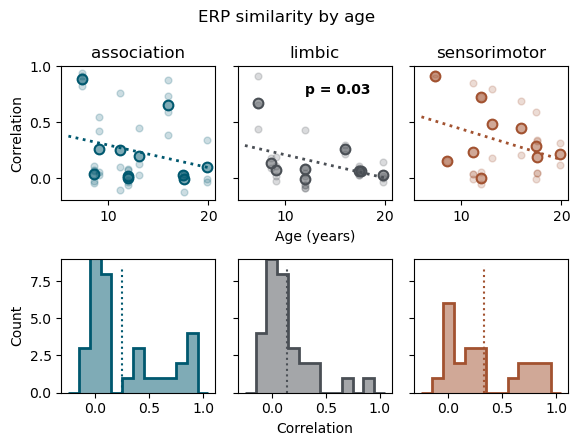

In [11]:
# SCH color palette
dblue = np.array([0, 88, 111])/255
dorange = np.array([162, 82, 48])/255
dgrey = np.array([74, 79, 85])/255

var = "avgcorr"
# cat = "neutral" &(gby.category==cat)
fig,ax = plt.subplots(2,3,figsize=(6,4.5), tight_layout=True)
syscol = [dblue,dgrey,dorange]

bins = np.linspace(-0.25,1.05,14)
# bins = np.linspace(0,5,21)

for ix,sys in enumerate(ERP_df.system.unique()):
    print(sys)
    sysgby = gby.loc[(gby.variable==var)&(gby.system==sys),:].sort_values(by="age")
    sysdf = ERP_df.loc[(ERP_df.variable==var)&(ERP_df.system==sys),:].sort_values(by="age")

    res = sm.OLS(sysdf.value,sm.add_constant(sysdf.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
    p = res.pvalues["age"]
    print(f"p = {p}")
    print(f"r^2 = {res.rsquared_adj}")
    print(f"n = {res.nobs}")
    print(f"t = {res.tvalues["age"]}")

    xreg = np.linspace(6,20,15)
    yreg = res.params.const+res.params.age*xreg
    
    ax[0,ix].scatter(data=sysdf,x="age", y="value", color=syscol[ix], alpha=0.2, s=24)
    ax[0,ix].scatter(data=sysgby, x="age", y="value", facecolor=np.concat([syscol[ix],(0.5,)]),
                     edgecolor=syscol[ix], lw=1.5, s=49)
    ax[0,ix].plot(xreg, yreg, color=syscol[ix], linestyle=":", linewidth=2)
    ax[0,ix].set_title(sys)
    
    ax[1,ix].hist(data=sysdf,x="value", bins=bins, color=syscol[ix], histtype='step', linewidth=2)
    ax[1,ix].hist(data=sysdf,x="value", bins=bins, color=syscol[ix], histtype='stepfilled', linewidth=0, alpha=0.5)
    ax[1,ix].plot(np.ones(2)*sysdf.value.mean(),[0,8.5],color=syscol[ix], linestyle=":")
    if p < 0.05:
        ax[0,ix].text(12, 0.75, f"p = {round(p,3)}", fontweight="bold")

ax[1,0].set_ylabel("Count")
ax[0,0].set_ylabel("Correlation")
ax[1,1].set_xlabel("Correlation")
ax[0,1].set_xlabel("Age (years)")


[ax[0,ix].set_ylim([-0.2,1]) for ix in range(ax.shape[1])]
[ax[1,ix].set_ylim([0,9]) for ix in range(ax.shape[1])]
[ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
[ax[1,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]

fig.suptitle("ERP similarity by age")
plt.show()

In [8]:
corrdf = ERP_df.loc[(ERP_df.variable=='avgcorr'),:].sort_values(by="age")
corrdf

,ID,age,region,contacts,value,variable,category,system
324,69037f,7.33,l_middletemporal,LE10-LE9,0.196070,avgcorr,all,association
311,69037f,7.33,l_Hip,LC2-LC1,0.645771,avgcorr,all,limbic
285,69037f,7.33,l_lateralorbitofrontal,LO6-LO5,0.625659,avgcorr,all,limbic
298,69037f,7.33,l_precentral,LN11-LN10,0.147181,avgcorr,all,sensorimotor
272,69037f,7.33,l_parstriangularis,LO14-LO13,0.463354,avgcorr,all,association
...,...,...,...,...,...,...,...,...
1104,ea2142,19.83,r_fusiform,RB_7-RB_6,0.584517,avgcorr,all,sensorimotor
1117,ea2142,19.83,r_Amy,RB_3-RB_2,0.096788,avgcorr,all,limbic
1130,ea2142,19.83,r_superiorfrontal,RQ_9-RQ_8,0.207401,avgcorr,all,association
1143,ea2142,19.83,r_rostralmiddlefrontal,RO_9-RO_8,0.732185,avgcorr,all,association


In [9]:
import statsmodels.formula.api as smf
corrdf = ERP_df.loc[(ERP_df.variable=='avgcorr'),:].sort_values(by="age")
res = smf.ols('value ~ C(system)*age',data=corrdf, hasconst=True).fit(cov_type="nonrobust", use_t=True)
display(res.summary2())

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Results: Ordinary least squares
============================================================================
Model:                  OLS                 Adj. R-squared:        0.058    
Dependent Variable:     value               AIC:                   12.1363  
Date:                   2026-07-02 13:48    BIC:                   27.0681  
No. Observations:       89                  Log-Likelihood:        -0.068132
Df Model:               5                   F-statistic:           2.086    
Df Residuals:           83                  Prob (F-statistic):    0.0753   
R-squared:              0.112               Scale:                 0.062879 
----------------------------------------------------------------------------
                               Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
----------------------------------------------------------------------------
Intercept                      0.6858   0.1350  5.0803 0.0000  0.4173 0.9543
C(system)[T.limbic]            0.1485   0.2042  0.7273 0.4691 -0.2576 0.5546
C(system)[T.sensorimotor]     -0.2762   0.2449 -1.1278 0.2627 -0.7632 0.2109
age                           -0.0201   0.0103 -1.9518 0.0543 -0.0406 0.0004
C(system)[T.limbic]:age       -0.0050   0.0150 -0.3311 0.7414 -0.0348 0.0248
C(system)[T.sensorimotor]:age  0.0255   0.0175  1.4596 0.1482 -0.0093 0.0603
----------------------------------------------------------------------------
Omnibus:                  3.412            Durbin-Watson:              1.649
Prob(Omnibus):            0.182            Jarque-Bera (JB):           2.126
Skew:                     -0.151           Prob(JB):                   0.345
Kurtosis:                 2.305            Condition No.:              164  
============================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is
correctly specified.
"""

,ID,age,region,contacts,value,variable,category,system
949,d5fe6f,13.08,r_precentral,RN10-RN9,8.533583,normamp,anger,sensorimotor
952,d5fe6f,13.08,r_precentral,RN10-RN9,10.479738,normamp,fear,sensorimotor
955,d5fe6f,13.08,r_precentral,RN10-RN9,8.634077,normamp,neutral,sensorimotor
958,d5fe6f,13.08,r_precentral,RN10-RN9,14.362319,normamp,happy,sensorimotor
962,d5fe6f,13.08,r_inferiorparietal,RU7-RU6,6.259786,normamp,anger,association
965,d5fe6f,13.08,r_inferiorparietal,RU7-RU6,7.337699,normamp,fear,association
968,d5fe6f,13.08,r_inferiorparietal,RU7-RU6,6.707226,normamp,neutral,association
971,d5fe6f,13.08,r_inferiorparietal,RU7-RU6,9.267525,normamp,happy,association
975,d5fe6f,13.08,r_fusiform,RF2-RF1,7.472758,normamp,anger,sensorimotor
978,d5fe6f,13.08,r_fusiform,RF2-RF1,7.568161,normamp,fear,sensorimotor


<Axes: >

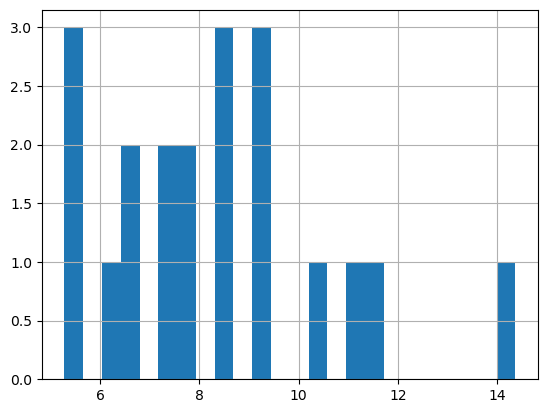

In [30]:
amps = ERP_df.loc[(ERP_df.variable=="normamp")&(ERP_df.ID==ERP_df.ID.unique()[9]),:]
display(amps)
amps.value.hist(bins=np.linspace(amps.value.min(),amps.value.max(),25))

association
p = 0.6326514485691969
r^2 = -0.021782804143301915
limbic
p = 0.43080770096394727
r^2 = -0.012605698947965038
sensorimotor
p = 0.4783049673772553
r^2 = -0.023286229164160677


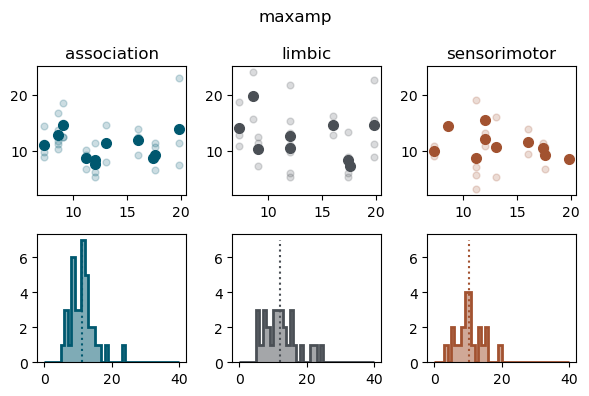

In [10]:
# max amps
maxamps = ERP_df.loc[ERP_df.variable=="normamp",:].groupby(by=["ID","system","region","contacts"]).agg(
    {"age":"mean","value":"max"}).reset_index().sort_values(by=["age",'ID'])

bins = np.linspace(0,40,41)
ampgby = maxamps.groupby(by=["ID","system"]).agg({"value":"mean","age":"mean"}).sort_values(by="age").reset_index()
fig,ax = plt.subplots(2,3,figsize=(6,4), tight_layout=True)

for ix,sys in enumerate(ERP_df.system.unique()):
    print(sys)
    sysgby = ampgby.loc[(ampgby.system==sys),:].sort_values(by="age")
    sysdf = maxamps.loc[(maxamps.system==sys),:].sort_values(by="age")

    res = sm.OLS(sysdf.value,sm.add_constant(sysdf.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
    print(f"p = {res.pvalues["age"]}")
    print(f"r^2 = {res.rsquared_adj}")

    xreg = np.linspace(6,20,15)
    
    ax[0,ix].scatter(data=sysdf,x="age", y="value", color=syscol[ix], alpha=0.2, s=24)
    ax[0,ix].scatter(data=sysgby, x="age", y="value",color=syscol[ix], s=49)
    ax[0,ix].set_title(sys)
    
    ax[1,ix].hist(data=sysdf,x="value", bins=bins, color=syscol[ix], histtype='step', linewidth=2)
    ax[1,ix].hist(data=sysdf,x="value", bins=bins, color=syscol[ix], histtype='stepfilled', linewidth=0, alpha=0.5)
    ax[1,ix].plot(np.ones(2)*sysdf.value.mean(),[0,7],color=syscol[ix], linestyle=":")

[ax[0,ix].sharey(ax[0,0]) for ix in range(ax.shape[1])]
[ax[1,ix].sharey(ax[1,0]) for ix in range(ax.shape[1])]
# [ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
# [ax[1,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]

fig.suptitle("maxamp")
plt.show()

association
p = 0.6404138600250807
r^2 = -0.022087304622233406
limbic
p = 0.1424234395491603
r^2 = 0.042209012170044136
sensorimotor
p = 0.16758698316844467
r^2 = 0.04764636866307603


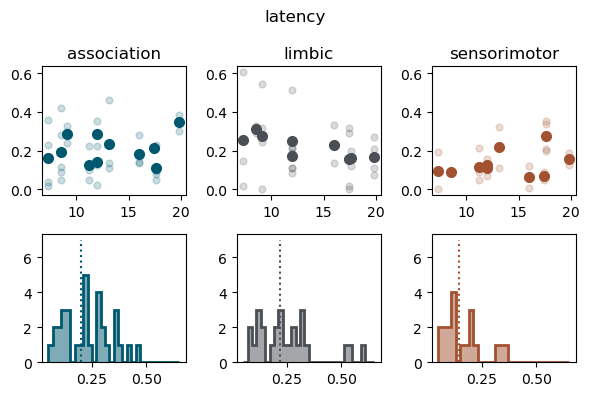

In [11]:
# min latencies
minlat = ERP_df.loc[ERP_df.variable=="latency",:].groupby(by=["ID","system","region","contacts"]).agg(
    {"age":"mean","value":"min"}).reset_index().sort_values(by=["age",'ID'])

bins = np.linspace(0.05,0.65,31)
latgby = minlat.groupby(by=["ID","system"]).agg({"value":"mean","age":"mean"}).sort_values(by="age").reset_index()
fig,ax = plt.subplots(2,3,figsize=(6,4), tight_layout=True)

for ix,sys in enumerate(ERP_df.system.unique()):
    print(sys)
    sysgby = latgby.loc[(latgby.system==sys),:].sort_values(by="age")
    sysdf = minlat.loc[(minlat.system==sys),:].sort_values(by="age")

    res = sm.OLS(sysdf.value,sm.add_constant(sysdf.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
    print(f"p = {res.pvalues["age"]}")
    print(f"r^2 = {res.rsquared_adj}")

    xreg = np.linspace(6,20,15)
    
    ax[0,ix].scatter(data=sysdf,x="age", y="value", color=syscol[ix], alpha=0.2, s=24)
    ax[0,ix].scatter(data=sysgby, x="age", y="value",color=syscol[ix], s=49)
    ax[0,ix].set_title(sys)
    
    ax[1,ix].hist(data=sysdf,x="value", bins=bins, color=syscol[ix], histtype='step', linewidth=2)
    ax[1,ix].hist(data=sysdf,x="value", bins=bins, color=syscol[ix], histtype='stepfilled', linewidth=0, alpha=0.5)
    ax[1,ix].plot(np.ones(2)*sysdf.value.mean(),[0,7],color=syscol[ix], linestyle=":")

[ax[0,ix].sharey(ax[0,0]) for ix in range(ax.shape[1])]
[ax[1,ix].sharey(ax[1,0]) for ix in range(ax.shape[1])]
# [ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
# [ax[1,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]

fig.suptitle("latency")
plt.show()

association
limbic
sensorimotor


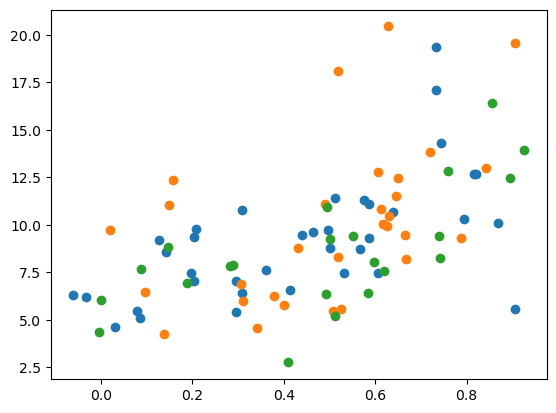

In [12]:
gby = ERP_df.groupby(by=["age","ID","system","contacts","variable"]).agg({"value":"mean"}).sort_values(by=["age","ID"]).reset_index()
corrs = gby.loc[gby.variable=="avgcorr","value"]
amps = gby.loc[gby.variable=="normamp","value"]

for sys in gby.system.unique():
    print(sys)
    plt.scatter(corrs[gby.system==sys],amps[gby.system==sys])
plt.show()